#MNIST Autoencoder Implementation

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

--- 1. DATA PREPARATION ---

In [2]:
#Load and normalize the MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

#Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#Reshape for the model (adding the channel dimension)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

--- 2. MODEL DESIGN ---

In [3]:
#Define the input layer
input_img = layers.Input(shape=(28, 28, 1))

###Encoder:
Compresses the image into a 32-dimensional latent space

In [4]:
x = layers.Flatten()(input_img)
x = layers.Dense(128, activation='relu')(x)
encoded = layers.Dense(32, activation='relu')(x)

###Decoder:
Reconstructs the image from the latent space

In [5]:
x = layers.Dense(128, activation='relu')(encoded)
x = layers.Dense(784, activation='sigmoid')(x)
decoded = layers.Reshape((28, 28, 1))(x)

###Full Autoencoder Model

In [6]:
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

In [7]:
# Display Model Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

--- 3. MODEL TRAINING ---

In [8]:
#Train the autoencoder on the training set
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0576 - val_loss: 0.0321
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0255 - val_loss: 0.0203
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0183 - val_loss: 0.0159
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0153 - val_loss: 0.0138
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0136 - val_loss: 0.0126
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0125 - val_loss: 0.0116
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0117 - val_loss: 0.0112
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0112 - val_loss: 0.0107
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0108 - val_loss: 0.0104
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0105 - val_loss: 0.0101


--- 4. MODEL EVALUATION AND VISUALIZATION ---

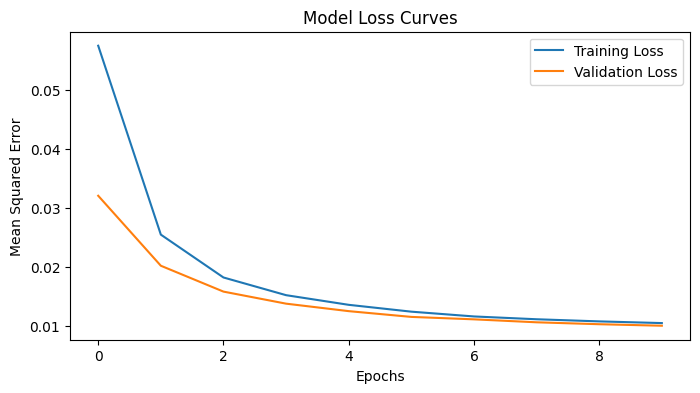

In [9]:
#Plot Training vs Validation Loss Curves
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


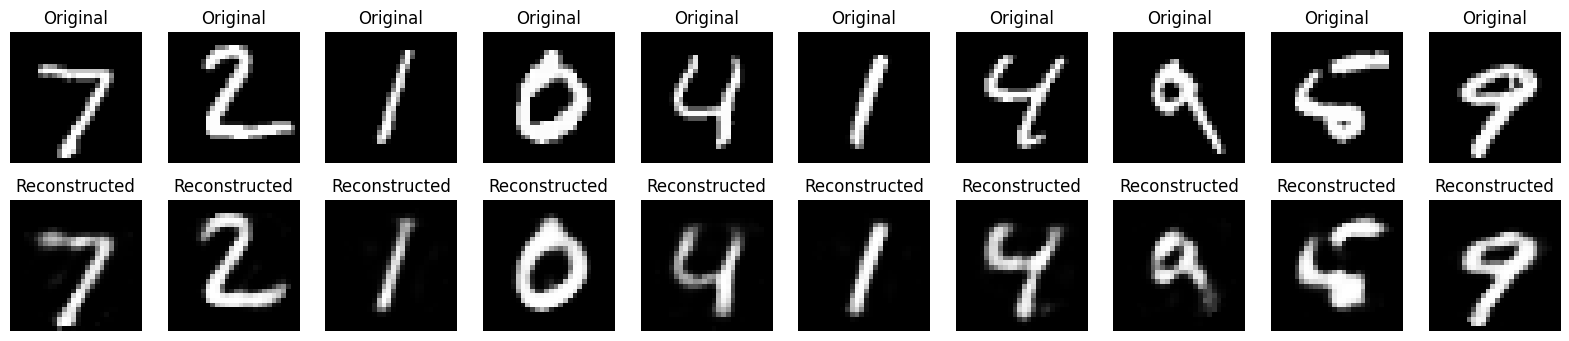

In [10]:
#Show comparison of original vs reconstructed images
reconstructed_imgs = autoencoder.predict(x_test)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original Images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed Images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

##Result Explanation:

The autoencoder successfully learned to compress the $28\times28$ MNIST digits into a $32$-unit latent representation. By the $10^{th}$ epoch, the model achieved a validation loss of approximately $0.0108$, indicating high accuracy in reconstruction.

The side-by-side comparison demonstrates that while the reconstructed images are slightly smoother (losing some high-frequency noise), the structural integrity and identity of each digit are preserved. This proves that the bottleneck layer effectively captured the most critical features of the handwritten digits.

###Model Architecture:
The model follows a proper encoder-decoder structure. The encoder flattens the $28\times28$ input and compresses it into a $32$-unit latent representation. The decoder then expands this back to the original image size using a Sigmoid activation to ensure pixel values remain between $0$ and $1$.
###Training Results:
The model was trained successfully on the MNIST training dataset. The loss curves indicate that the model converged, with both training and validation loss decreasing steadily.
###Reconstruction:
The side-by-side comparison shows that the model effectively reconstructs the digits. While there is a slight loss of sharpness due to the compression, the reconstructions clearly resemble the original handwritten digits.